# 7 · `scatter`

`Map.scatter` plots an arbitrary point `FeatureCollection`, coloured by its first numeric column (cleopatra `ScatterGlyph`). Here we vectorise the DEM cell centres into a `FeatureCollection`.

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 10)   # downsample for legible markers/cells
from pyramids.feature import FeatureCollection

Build a point `FeatureCollection` with an elevation column and scatter it.

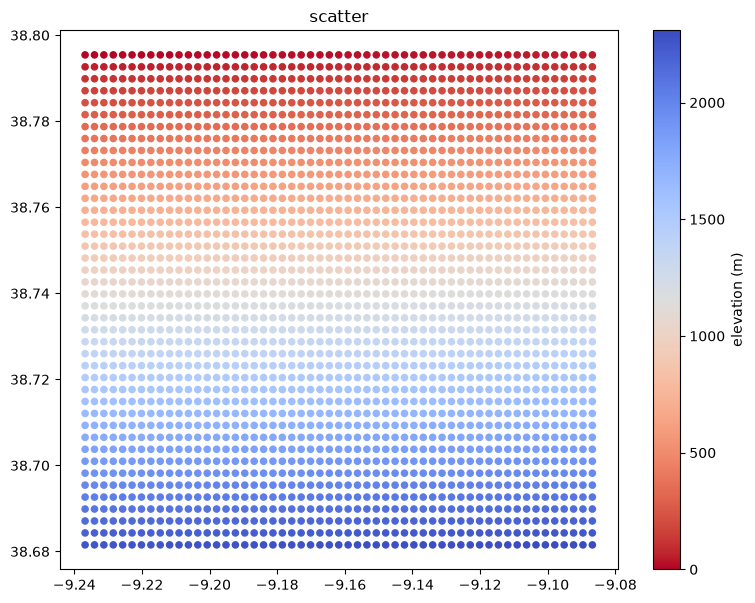

In [2]:
pts = coarse.get_cell_points()
pts['elevation'] = coarse.read_array(band=0).astype('float64').ravel()
fc = FeatureCollection(pts)
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.scatter(fc)
m.colorbar(label='elevation (m)')
m.set_title('scatter')
m.fig;